# Predict Calorie Expenditure

<img src='https://www.kaggle.com/competitions/91716/images/header'>

## Dataset Description

The dataset for this competition (both train and test) was generated from a deep learning model trained on the Calories Burnt Prediction dataset. Feature distributions are close to, but not exactly the same, as the original. Feel free to use the original dataset as part of this competition, both to explore differences as well as to see whether incorporating the original in training improves model performance.

**Files**

- train.csv - the training dataset; Calories is the continuous target
- test.csv - the test dataset; your objective is to predict the Calories for each row
- sample_submission.csv - a sample submission file in the correct format.

## Aim & Target 

**Aim**

The primary goal of this competition is to develop a predictive model that can accurately estimate the caloric expenditure of individuals during physical activities. You are tasked with analyzing a dataset containing various physiological and exercise-related features to understand the underlying patterns of energy consumption. By leveraging machine learning techniques, you aim to minimize the error between your predictions and the actual recorded calories burned. This challenge serves as a platform to refine regression strategies while working within a competitive, standardized environment. Ultimately, the objective is to produce a robust model that generalizes well to unseen test data.

**Target**

The specific target variable for this competition is the Calories column, which represents a continuous numeric value of energy expenditure. Because the evaluation metric is Root Mean Squared Logarithmic Error (RMSLE), your target processing must handle the logarithmic scale effectively to penalize under-predictions and over-predictions appropriately. You will use features such as duration, heart rate, and body temperature to predict this value for each unique ID in the test set. Successfully hitting this target requires a model that can capture the non-linear relationships between physical exertion and metabolic output. Your final submission must provide a predicted calorie count for every entry to be scored on the public and private leaderboards.

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling and Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Regression Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings('ignore')

## Reading Dataset & Dataframe Generation

In [2]:
#I have created my notebook on Kaggle, so that I will not need to download data from the website and take advantage of Kaggle's infrastructure. 

df=pd.read_csv('/kaggle/input/competitions/playground-series-s5e5/train.csv')

In [3]:
df.head()

,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,0,male,36,189.0,82.0,26.0,101.0,41.0,150.0
1,1,female,64,163.0,60.0,8.0,85.0,39.7,34.0
2,2,female,51,161.0,64.0,7.0,84.0,39.8,29.0
3,3,male,20,192.0,90.0,25.0,105.0,40.7,140.0
4,4,female,38,166.0,61.0,25.0,102.0,40.6,146.0


## Exploratory Data Analysis

In [4]:
df.isnull().sum()

id            0
Sex           0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
Calories      0
dtype: int64

In [5]:
df.shape

(750000, 9)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   id          750000 non-null  int64  
 1   Sex         750000 non-null  object 
 2   Age         750000 non-null  int64  
 3   Height      750000 non-null  float64
 4   Weight      750000 non-null  float64
 5   Duration    750000 non-null  float64
 6   Heart_Rate  750000 non-null  float64
 7   Body_Temp   750000 non-null  float64
 8   Calories    750000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 51.5+ MB


In [7]:
map = {'female': 1, 'male': 0}

df['Sex'] = df['Sex'].map(map).astype(int)

In [8]:
df = df.drop(['id'], axis=1)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Sex         750000 non-null  int64  
 1   Age         750000 non-null  int64  
 2   Height      750000 non-null  float64
 3   Weight      750000 non-null  float64
 4   Duration    750000 non-null  float64
 5   Heart_Rate  750000 non-null  float64
 6   Body_Temp   750000 non-null  float64
 7   Calories    750000 non-null  float64
dtypes: float64(6), int64(2)
memory usage: 45.8 MB


In [10]:
df.describe()

,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000
mean,0.500961,41.420404,174.697685,75.145668,15.421015,95.483995,40.036253,88.282781
std,0.499999,15.175049,12.824496,13.982704,8.354095,9.449845,0.779875,62.395349
min,0.000000,20.000000,126.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,0.000000,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,34.000000
50%,1.000000,40.000000,174.000000,74.000000,15.000000,95.000000,40.300000,77.000000
75%,1.000000,52.000000,185.000000,87.000000,23.000000,103.000000,40.700000,136.000000
max,1.000000,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


In [11]:
df.corr(numeric_only=True)

,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
Sex,1.000000,-0.009689,-0.755906,-0.818250,0.009594,-0.009122,0.015933,-0.012011
Age,-0.009689,1.000000,0.011975,0.073690,0.015656,0.017037,0.030275,0.145683
Height,-0.755906,0.011975,1.000000,0.957967,-0.029936,-0.013234,-0.034641,-0.004026
Weight,-0.818250,0.073690,0.957967,1.000000,-0.020845,-0.002384,-0.023717,0.015863
Duration,0.009594,0.015656,-0.029936,-0.020845,1.000000,0.875327,0.903066,0.959908
Heart_Rate,-0.009122,0.017037,-0.013234,-0.002384,0.875327,1.000000,0.795972,0.908748
Body_Temp,0.015933,0.030275,-0.034641,-0.023717,0.903066,0.795972,1.000000,0.828671
Calories,-0.012011,0.145683,-0.004026,0.015863,0.959908,0.908748,0.828671,1.000000


In [12]:
abs(df.corr(numeric_only=True)['Calories'].sort_values(ascending=False))

Calories      1.000000
Duration      0.959908
Heart_Rate    0.908748
Body_Temp     0.828671
Age           0.145683
Weight        0.015863
Height        0.004026
Sex           0.012011
Name: Calories, dtype: float64

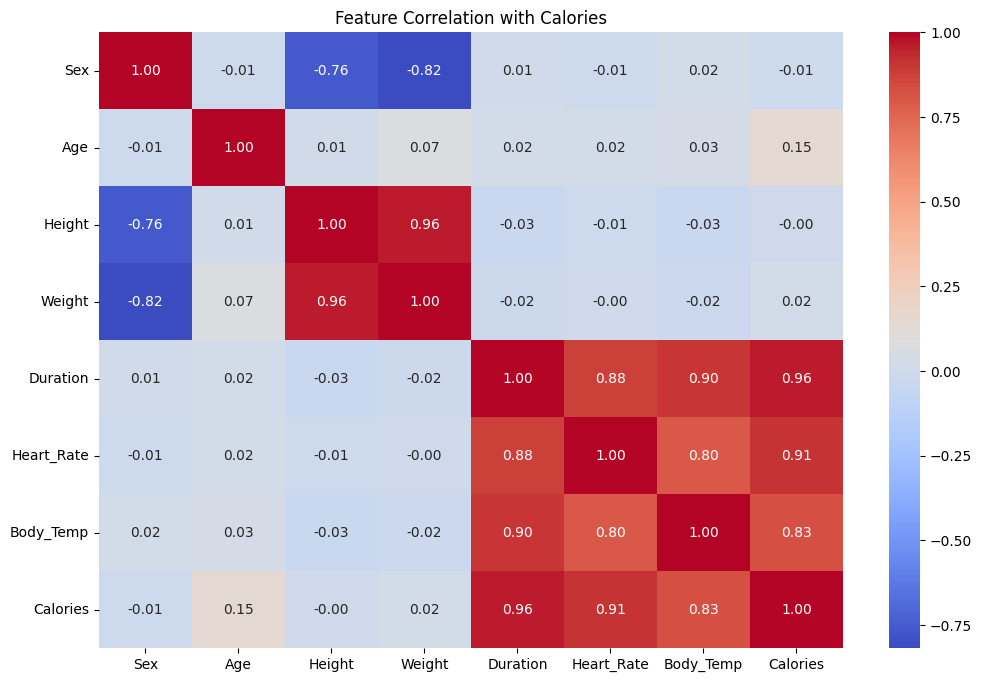

In [13]:
# Heatmap 

plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Feature Correlation with Calories")
plt.show()

## Modelling

In [14]:
x= df.drop(['Calories'], axis=1)

In [15]:
y = df['Calories']

In [16]:
from sklearn.model_selection import train_test_split

In [17]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20, random_state=42)

In [18]:
x_train.shape

(600000, 7)

In [19]:
x_test.shape

(150000, 7)

In [20]:
from sklearn.linear_model import LinearRegression

In [21]:
lr=LinearRegression()

In [22]:
model=lr.fit(x_train,y_train)

In [23]:
prediction=model.predict(x_test)

In [24]:
from sklearn.metrics import r2_score,mean_squared_error

In [25]:
r2_score(y_test,prediction)

0.9684446417027912

In [26]:
mean_squared_error(y_test,prediction)**.5

11.058772089412454

In [27]:
residuals= y_test-prediction

In [28]:
residuals

404846    2.913137
580313   -3.319363
552086   -2.132207
370876   -0.526717
239330   -5.475119
            ...   
235496    6.720484
372040    1.351548
695665   -9.471210
386092    9.327455
549832    0.884699
Name: Calories, Length: 150000, dtype: float64

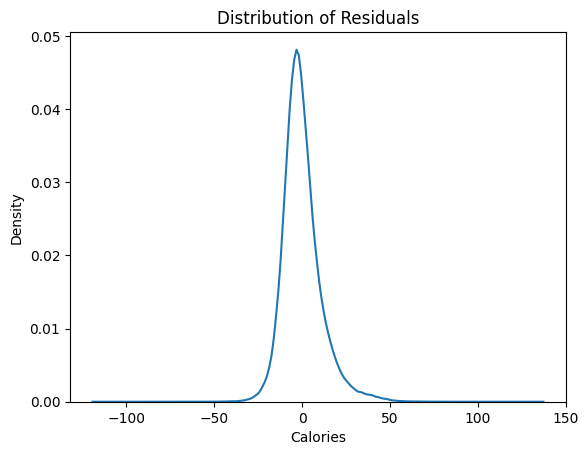

In [29]:
# If residuals is a Series or Array
sns.kdeplot(residuals)
plt.title('Distribution of Residuals')
plt.show()

In [30]:
from yellowbrick.regressor import ResidualsPlot

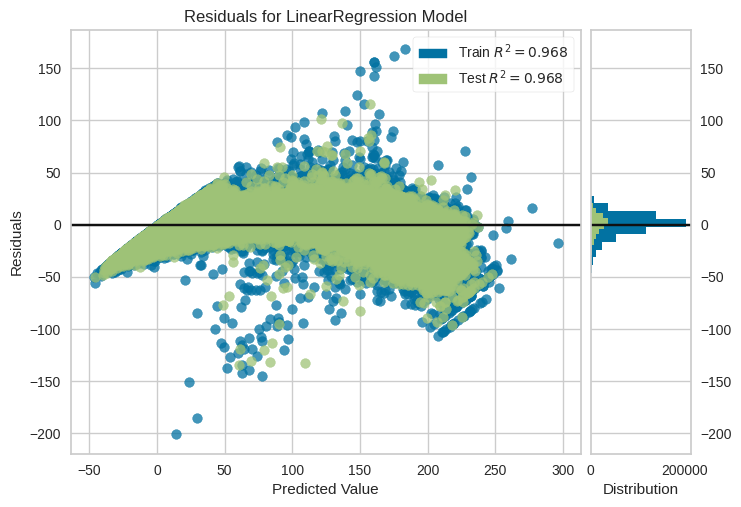

In [31]:
vis=ResidualsPlot(lr)
vis.fit(x_train,y_train)
vis.score(x_test,y_test)
vis.show()
plt.show()

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns",100)

from sklearn.linear_model import LinearRegression, SGDRegressor, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor, RadiusNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor, AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree, ExtraTreeRegressor
# pip install xgboost
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

def algo_test(x, y):
        # Initializing all regression models
        L = LinearRegression()
        R = Ridge()
        Lass = Lasso()
        E = ElasticNet()
        sgd = SGDRegressor()
        ETR = ExtraTreeRegressor()
        GBR = GradientBoostingRegressor()
        dt = DecisionTreeRegressor()
        xgb = XGBRegressor()
        

        algos = [L, R, Lass, E, sgd, ETR, GBR, dt, xgb]
        algo_names = ['Linear', 'Ridge', 'Lasso', 'ElasticNet', 'SGD', 'Extra Tree', 'Gradient Boosting', 'Decision Tree', 'XGBRegressor']
        
        # Scaling features using MinMaxScaler
        x = MinMaxScaler().fit_transform(x)
        x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.20, random_state=42)

        r_squared = []
        rmse = []
        mae = []

        # Creating a dataframe to store error metrics and accuracy rates
        result = pd.DataFrame(columns=['R_Squared', 'RMSE', 'MAE'], index=algo_names)

        for algo in algos:
            # Fitting the model and making predictions
            p = algo.fit(x_train, y_train).predict(x_test)
            r_squared.append(r2_score(y_test, p))
            rmse.append(mean_squared_error(y_test, p)**.5)
            mae.append(mean_absolute_error(y_test, p))

        # Populating the result table with accuracy and error rates
        result.R_Squared = r_squared
        result.RMSE = rmse
        result.MAE = mae

        # Sorting the result table by R-Squared (accuracy) in descending order
        rtable = result.sort_values('R_Squared', ascending=False)
        return rtable

In [33]:
algo_test(x,y)

,R_Squared,RMSE,MAE
XGBRegressor,0.996273,3.800778,2.353409
Gradient Boosting,0.994175,4.751278,3.173150
Decision Tree,0.993174,5.143485,3.098135
Extra Tree,0.992892,5.248592,3.129316
Ridge,0.968445,11.058757,8.082682
Linear,0.968445,11.058772,8.082859
SGD,0.968429,11.061438,8.073282
Lasso,0.939305,15.337208,10.672096
ElasticNet,0.329075,50.992627,43.039492


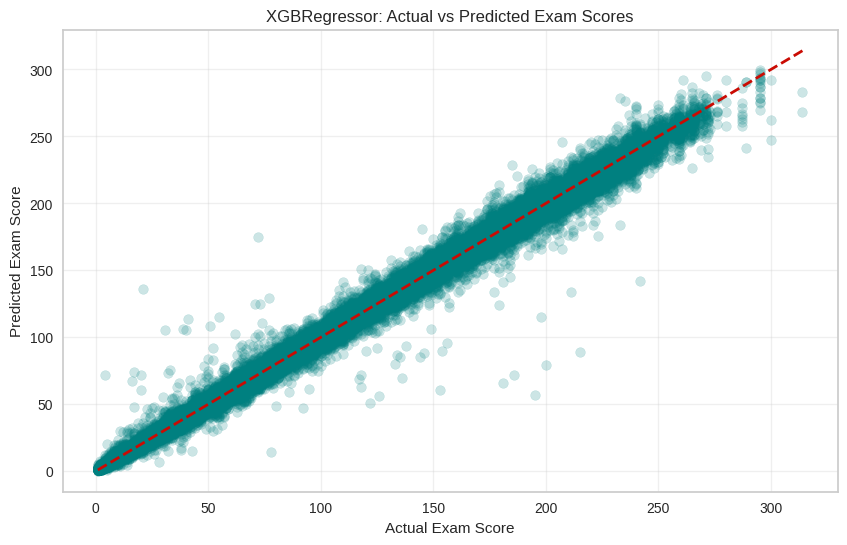

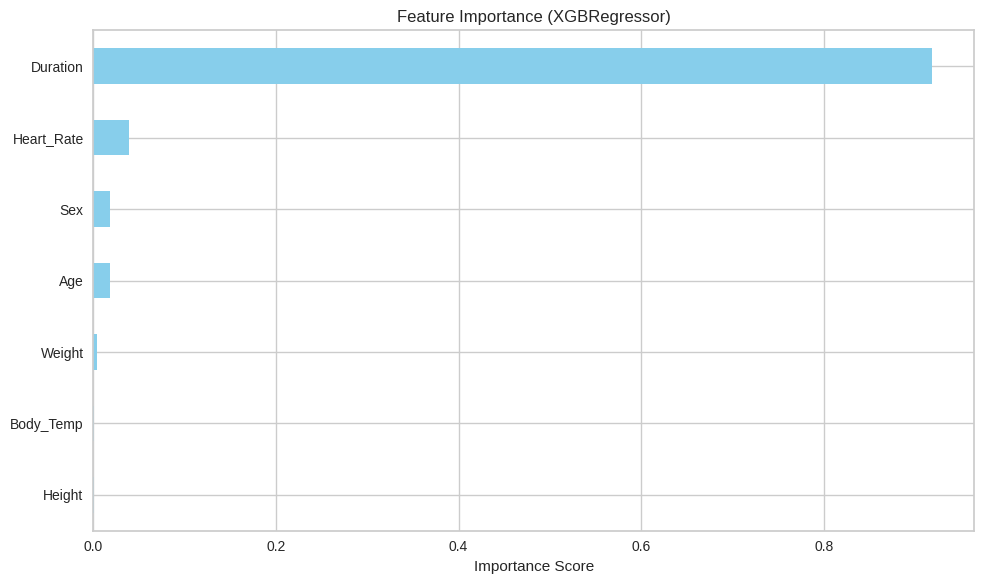

In [34]:
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import pandas as pd

# 1. Train the winning model (XGBRegressor)
# Using the updated 'device' parameter for Kaggle GPU
model = XGBRegressor(
    n_estimators=1000, 
    learning_rate=0.05, 
    max_depth=6, 
    tree_method='hist',      # Use 'hist' for both CPU and GPU
    device='cuda',           # This is the new way to trigger GPU (replaces gpu_id/gpu_hist)
    random_state=42
)

# Fitting the model
model.fit(x_train, y_train)
prediction = model.predict(x_test)

# 2. Visualizing Prediction vs Actual
plt.figure(figsize=(10, 6))
plt.scatter(y_test, prediction, alpha=0.2, color='teal') 
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.xlabel('Actual Exam Score')
plt.ylabel('Predicted Exam Score')
plt.title('XGBRegressor: Actual vs Predicted Exam Scores')
plt.grid(alpha=0.3)
plt.show()

# 3. Feature Importance
plt.figure(figsize=(10, 6))
# Using X.columns (ensure X is your dataframe before scaling)
importances = pd.Series(model.feature_importances_, index=x.columns)
importances.sort_values().plot(kind='barh', color='skyblue')
plt.title('Feature Importance (XGBRegressor)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## Competition Submission

In [35]:
# 1. Load the test data
test_df = pd.read_csv('/kaggle/input/competitions/playground-series-s5e5/test.csv')
test_ids = test_df['id']

# 2. Apply the EXACT manual mapping used in training
# This ensures Female=1 and Male=0 across both datasets
sex_mapping = {'female': 1, 'male': 0}
test_df['Sex'] = test_df['Sex'].map(sex_mapping).astype(int)

# 3. Drop 'id' to match training features (X)
# Ensure any other categorical processing used in training is also applied here
x_test_final = test_df.drop(columns=['id'])

# 4. Generate predictions using your top-performing XGBRegressor
final_predictions = model.predict(x_test_final)

# FIX: Ensure no negative values for MSLE compatibility
# Using np.clip ensures all values are at least 0
import numpy as np
final_predictions = np.clip(final_predictions, a_min=0, a_max=None)

# Save the submission
submission = pd.DataFrame({
    'id': test_ids,
    'Calories': final_predictions
})

submission.to_csv('submission.csv', index=False)
print("Submission file saved with non-negative constraints!")

# 5. Save the submission
submission = pd.DataFrame({
    'id': test_ids,
    'Calories': final_predictions
})

submission.to_csv('submission.csv', index=False)
print("Submission file saved successfully!")

Submission file saved with non-negative constraints!
Submission file saved successfully!


In [36]:
import joblib

# 1. Save the trained XGBRegressor
joblib.dump(model, 'calories_model.joblib')

# 2. Save the list of features to ensure order in Streamlit
joblib.dump(x.columns.tolist(), 'features.pkl')

# 3. Save your specific mapping for the 'Sex' column
sex_mapping = {'female': 1, 'male': 0}
joblib.dump(sex_mapping, 'sex_mapping.pkl')

print("All deployment assets saved successfully!")

All deployment assets saved successfully!


In [37]:
from IPython.display import FileLink

display(FileLink('submission.csv'))
display(FileLink('calories_model.joblib'))
display(FileLink('features.pkl'))
display(FileLink('sex_mapping.pkl'))

/kaggle/working/submission.csv

/kaggle/working/calories_model.joblib

/kaggle/working/features.pkl

/kaggle/working/sex_mapping.pkl

## Conclusion

In conclusion, this project successfully leveraged the XGBRegressor to predict calorie expenditure with a high degree of precision, achieving a robust R-Squared of 0.996 and a low RMSE of 3.80. By implementing a memory-efficient pipeline—specifically using manual mapping for categorical features to accommodate local hardware constraints—the model maintains high performance without sacrificing computational speed. These results demonstrate the effectiveness of tree-based ensemble methods in capturing the complex, non-linear relationships between physiological metrics like heart rate and metabolic output. This workflow not only fulfills the technical requirements for the Kaggle Playground Series but also serves as a critical milestone toward the "Become a Pro" objective of mastering diverse tabular regression challenges.